In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("/content/marketing_AB.csv")

In [3]:
df.head()

,Unnamed: 0,user id,test group,converted,total ads,most ads day,most ads hour
0,0,1069124,ad,False,130,Monday,20
1,1,1119715,ad,False,93,Tuesday,22
2,2,1144181,ad,False,21,Tuesday,18
3,3,1435133,ad,False,355,Tuesday,10
4,4,1015700,ad,False,276,Friday,14


In [4]:
df.duplicated('user id').sum()

0

In [5]:
df.drop(['Unnamed: 0', 'user id'], axis = 1, inplace=True)

In [6]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [8]:
#check if the categorical variables have appropriate number of levels
df_cat = df[['test group', 'converted', 'most ads day', 'most ads hour']]
df_cat.nunique()

,0
test group,2
converted,2
most ads day,7
most ads hour,24


In [9]:
for i in df_cat.columns:
  print(i.upper(), ":", df_cat[i].unique())

TEST GROUP : ['ad' 'psa']
CONVERTED : [False  True]
MOST ADS DAY : ['Monday' 'Tuesday' 'Friday' 'Saturday' 'Wednesday' 'Sunday' 'Thursday']
MOST ADS HOUR : [20 22 18 10 14 13 19 11 12 16 21  3 23  4  8  0  2 15  1  6 17  7  9  5]


Univariate Analysis

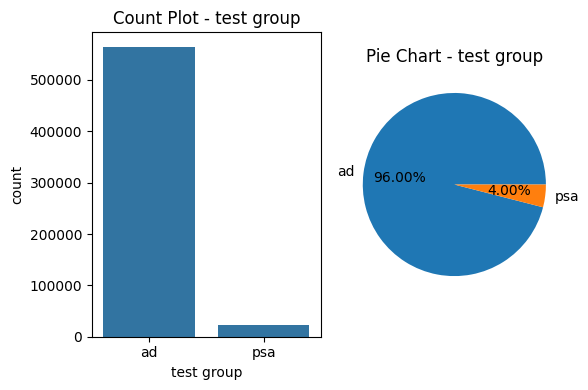

In [11]:
variable = 'test group'

plt.figure(figsize = (6,4))
#count plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}')

#Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

#Adjust layout
plt.tight_layout()
plt.show()

The charts represent that majority of the people were shown the ads and few prople were shown the general announcement.

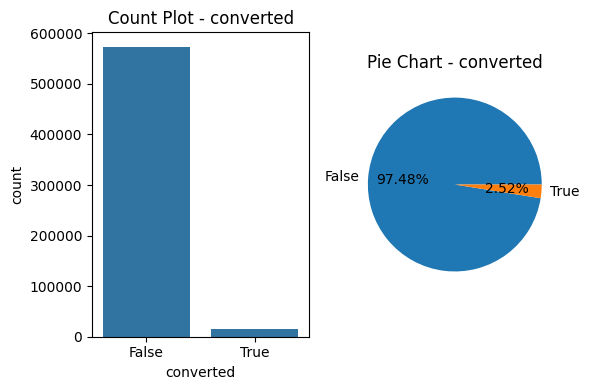

In [12]:
variable = 'converted'

plt.figure(figsize = (6,4))
#Count Plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat)
plt.title(f'Count Plot - {variable}')

#Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels = counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

plt.tight_layout()

plt.show()

Majority of the products weren't bought. Very little conversion rate

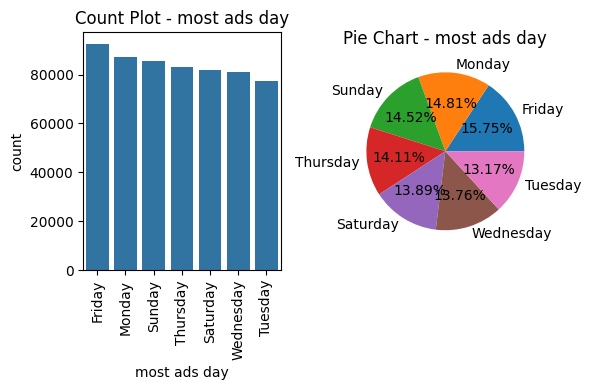

In [14]:
variable = 'most ads day'

plt.figure(figsize= (6,4))

#Count Plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat, order= df_cat['most ads day']. value_counts().index)
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)

#Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

plt.tight_layout()
plt.show()

Friday was the day with most ads

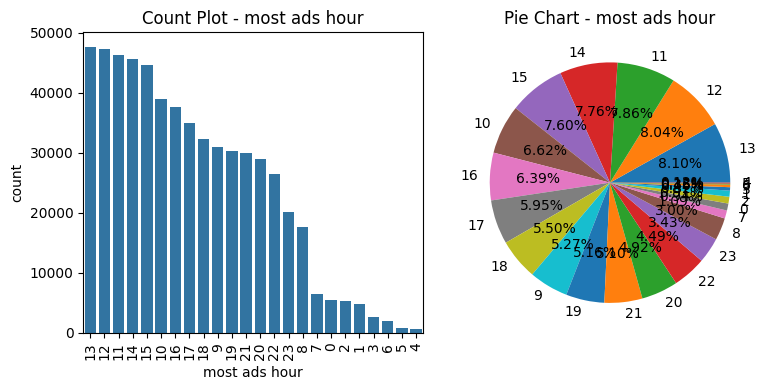

In [17]:
variable = 'most ads hour'

plt.figure(figsize= (8,4))

#Count Plot
plt.subplot(1,2,1)
sns.countplot(x=variable, data=df_cat, order= df_cat['most ads hour']. value_counts().index)
plt.title(f'Count Plot - {variable}')
plt.xticks(rotation = 90)

#Pie Chart
plt.subplot(1,2,2)
counts = df_cat[variable].value_counts()
plt.pie(counts, labels=counts.index, autopct='%0.2f%%')
plt.title(f'Pie Chart - {variable}')

plt.tight_layout()
plt.show()

Maximun ads were watched at 1 PM. i.e frequency of ads

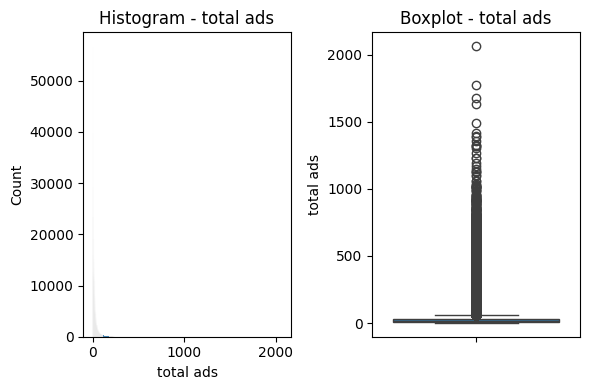

In [19]:
variable = 'total ads'

plt.figure(figsize = (6,4))

#Histogram
plt.subplot(1,2,1)
sns.histplot(x=variable, data=df)
plt.title(f'Histogram - {variable}')

#Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=variable, data=df)
plt.title(f'Boxplot - {variable}')

plt.tight_layout()
plt.show()

In [20]:
df['total ads'].describe()

,total ads
count,588101.000000
mean,24.820876
std,43.715181
min,1.000000
25%,4.000000
50%,13.000000
75%,27.000000
max,2065.000000


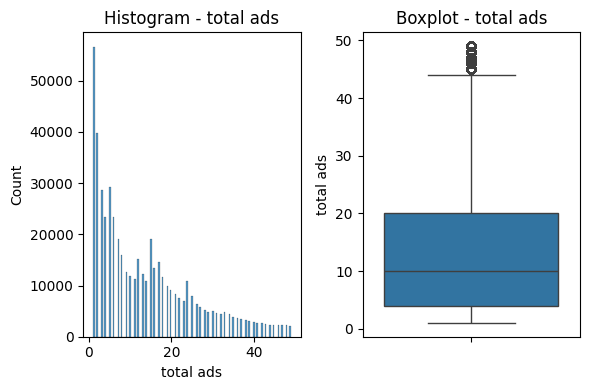

In [21]:
variable = 'total ads'

plt.figure(figsize = (6,4))

#Histogram
plt.subplot(1,2,1)
#Filtering the data fo value close to 75th percentike only
sns.histplot(x=variable, data=df[df['total ads'] < 50])
plt.title(f'Histogram - {variable}')

#Boxplot
plt.subplot(1,2,2)
sns.boxplot(y=variable, data=df[df['total ads'] < 50])
plt.title(f'Boxplot - {variable}')

plt.tight_layout()
plt.show()

Median can be seen as 10 ads but there are prople who have been shown the ads multiple times

# Bivariate Analysis


In [22]:
df.columns

Index(['test group', 'converted', 'total ads', 'most ads day',
       'most ads hour'],
      dtype='object')

In [23]:
 ct_conversion_test_group = pd.crosstab(df['test group'], df['converted'], normalize='index')
 ct_conversion_test_group

converted,False,True
test group,,
ad,0.974453,0.025547
psa,0.982146,0.017854


Out of all the people who has seen the ads only 2% of them made the purchase
and only 1.7% people have made the purchase after viewing the PSA

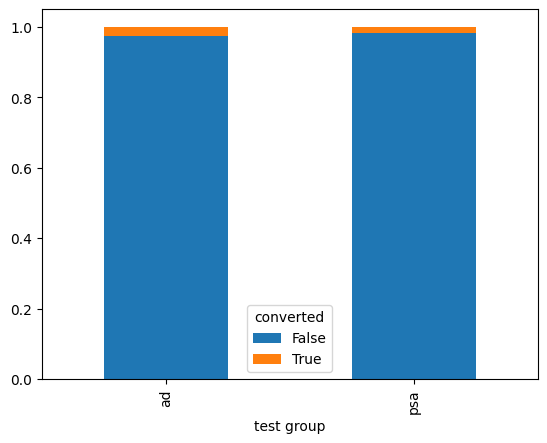

In [24]:
ct_conversion_test_group.plot.bar(stacked = True);

The conversion is low after viewing the ads

converted        False     True 
most ads day                    
Monday        0.967188  0.032812
Tuesday       0.970160  0.029840
Wednesday     0.975058  0.024942
Sunday        0.975524  0.024476
Friday        0.977788  0.022212
Thursday      0.978429  0.021571
Saturday      0.978949  0.021051


<Axes: xlabel='most ads day'>

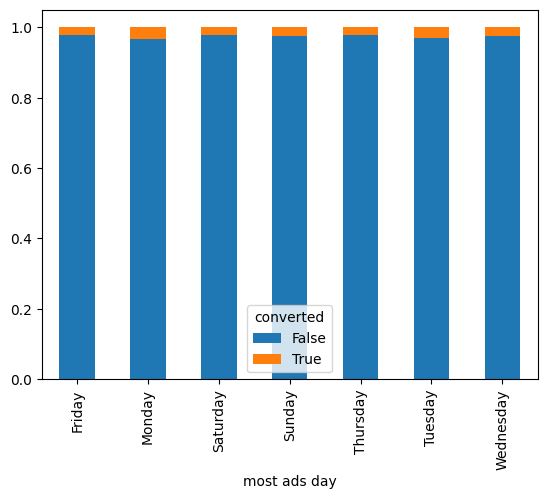

In [25]:
ct_conversion_days = pd.crosstab(df['most ads day'], df['converted'], normalize = 'index')
print(ct_conversion_days.sort_values(by = True, ascending = False))
ct_conversion_days.plot.bar(stacked = True);

Monday is the day where maximum conversion happened with tthe conversion rate of 3.2%

converted         False     True 
most ads hour                    
16             0.969228  0.030772
20             0.970197  0.029803
15             0.970347  0.029653
21             0.971077  0.028923
17             0.971790  0.028210
14             0.971937  0.028063
18             0.972620  0.027380
19             0.973280  0.026720
22             0.973895  0.026105
13             0.975323  0.024677
12             0.976172  0.023828
23             0.977338  0.022662
6              0.977756  0.022244
11             0.977884  0.022116
10             0.978479  0.021521
5              0.979085  0.020915
8              0.980484  0.019516
9              0.980809  0.019191
0              0.981575  0.018425
7              0.981889  0.018111
4              0.984765  0.015235
1              0.987089  0.012911
3              0.989548  0.010452
2              0.992687  0.007313


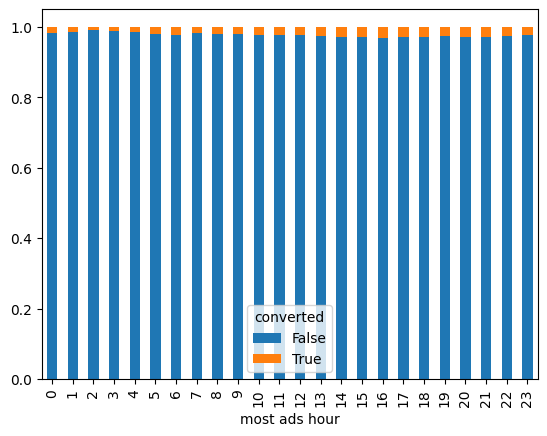

In [26]:
ct_conversion_days = pd.crosstab(df['most ads hour'], df['converted'], normalize = 'index')
print(ct_conversion_days.sort_values(by = True, ascending = False))
ct_conversion_days.plot.bar(stacked = True);

Conversion rate is the highest at 4 PM

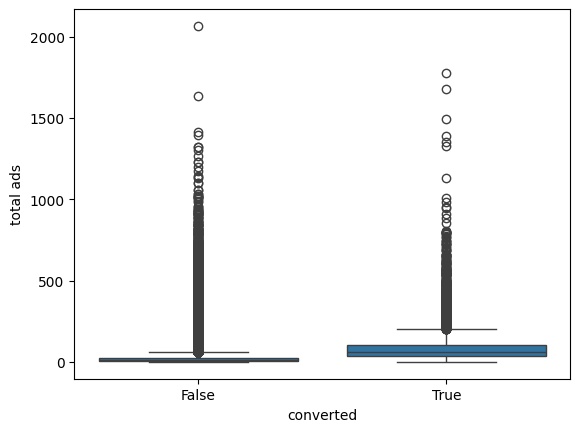

In [27]:
sns.boxplot(x= 'converted', y='total ads', data = df);

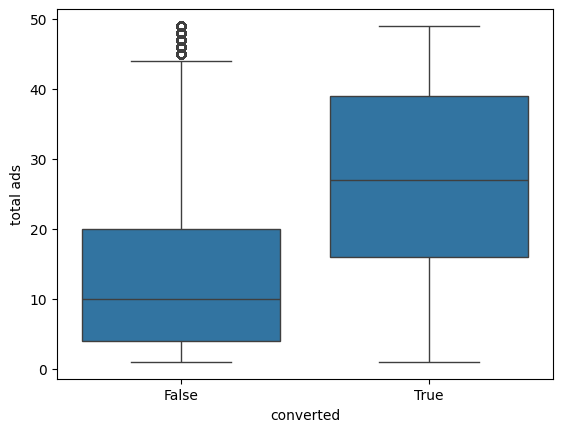

In [28]:
sns.boxplot(x= 'converted', y='total ads', data = df[df['total ads'] < 50]);

The median amounts of ads seen before purchasing is around 25
whereas, the median amount ads where no purchase has been made is around 10

Repeated targeting seems to be helping

# Statistical Tests

In [29]:
from scipy.stats import chi2_contingency
alpha = 0.05
for variable in df_cat.columns:
  if variable != 'converted':
    contingency_table = pd.crosstab(df_cat[variable], df_cat['converted'])

    chi2, p, _, _= chi2_contingency(contingency_table)

    print(f"\nChi-squared test for {variable} vs. converted:")
    print(f"Chi-squared value: {chi2}")
    print(f"p-value: {p}")

    if p < alpha:
      print(f"The difference in conversion rate across {variable} is statistically significant.")

    else:
      print(f"There is no significant difference in conversion rate across {variable}")


Chi-squared test for test group vs. converted:
Chi-squared value: 54.005823883685245
p-value: 1.9989623063390075e-13
The difference in conversion rate across test group is statistically significant.

Chi-squared test for most ads day vs. converted:
Chi-squared value: 410.0478857936585
p-value: 1.932184379244731e-85
The difference in conversion rate across most ads day is statistically significant.

Chi-squared test for most ads hour vs. converted:
Chi-squared value: 430.76869230822086
p-value: 8.027629823696771e-77
The difference in conversion rate across most ads hour is statistically significant.


In [31]:
df_cat.columns

Index(['test group', 'converted', 'most ads day', 'most ads hour'], dtype='object')

In [34]:
from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
#Step 1: Check Assumption
#Normality Assumption
shapiro_stat_true, shapiro_p_value_true = shapiro(df[df['converted'] == True]['total ads'])
shapiro_stat_false, shapiro_p_value_false = shapiro(df[df['converted'] == False]['total ads'])

print(f"Shapiro-Wik test for normality (True group): p-value = {shapiro_p_value_true}")
print(f"Shapiro-Wik test for normality (False group): p-value = {shapiro_p_value_false}")

#Equality of variances assumption
levene_stat, levene_p_value = levene(df[df['converted']] ['total ads'], df[~df['converted']]['total ads'])
print(f"Levene test for homogeneity of variances: p-value = {levene_p_value}")

Shapiro-Wik test for normality (True group): p-value = 1.638680987007771e-98
Shapiro-Wik test for normality (False group): p-value = 9.883049430735801e-204
Levene test for homogeneity of variances: p-value = 0.0


In [33]:
#Step 2: Perform a Suitable Test
alpha = 0.05

if shapiro_p_value_true > alpha and shapiro_p_value_false > alpha and levene_p_value > alpha:
  #Assumpion met - use t test for means
  t_stat, t_p_value = ttest_ind(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
  print(f"Independent two-sample t-test: p-value = {t_p_value}")

else:
  #Assumptions not met - use Mann-Whitney U test for medians
  u_stat, u_p_value = mannwhitneyu(df[df['converted']]['total ads'], df[~df['converted']]['total ads'])
  print(f"Mann-Whitney U test: p-value = {u_p_value}")

Mann-Whitney U test: p-value = 0.0
